# 2. Training and Evaluating Your First Model

This notebook trains a classifier on the diabetes data from chapter 1 and then spends most of its length attacking the number that comes out. That is deliberate. Training a model is three lines; knowing whether the result means anything is the actual skill, and it is where most applied machine learning goes wrong.

**You will learn:**

- what `fit` and `predict` do, and the one mistake that makes any model look perfect
- why a single train/test split gives you a number you cannot trust
- how to read a confusion matrix, and why accuracy hides the thing you care about
- that the 0.5 decision threshold is a choice, not a property of the model
- how cross-validation replaces one number with a distribution

**Prerequisites:** chapters 0 and 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tuiml.datasets import load_diabetes

data = load_diabetes()
X, y = data.X, data.y

print(data.shape, "|", dict(zip(data.target_names, np.bincount(y))))

(768, 8) | {'tested_negative': np.int64(500), 'tested_positive': np.int64(268)}


## 2.1 Fit and predict

Every supervised model in TuiML has the same two methods. `fit(X, y)` learns from labelled examples; `predict(X)` applies what it learned to new rows.

In [2]:
from tuiml.algorithms.trees import DecisionTreeClassifier
from tuiml.evaluation import accuracy_score

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X, y)

accuracy_score(y, tree.predict(X))

1.0

**100% accuracy.** We are done — the model diagnoses diabetes perfectly.

Obviously not. We asked the model to make predictions about the same 768 patients it had just memorised. A decision tree, left unconstrained, will keep splitting until every training row sits in its own leaf; asking it to recall them is a test of its memory, not of anything useful.

This is the cardinal sin of evaluation, and the reason it deserves a heading rather than a footnote: **the failure is silent.** No exception, no warning, just a beautiful number. If you ever see 1.00, assume you have done this until you have proved otherwise.

> **Remark.** The same mistake wears other disguises. Fitting a scaler on the full dataset before splitting, selecting features using the test labels, or tuning hyperparameters against the set you later report on are all versions of it. Chapter 3 covers the first, chapter 5 the second, chapter 7 the third.

## 2.2 Holding data back

The fix is to keep some data away from the model during training and score on that.

In [3]:
from tuiml.evaluation import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("train:", X_train.shape, "test:", X_test.shape)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print()
print(f"accuracy on training data: {accuracy_score(y_train, tree.predict(X_train)):.4f}")
print(f"accuracy on held-out data: {accuracy_score(y_test, tree.predict(X_test)):.4f}")

train: (616, 8) test: (152, 8)

accuracy on training data: 1.0000
accuracy on held-out data: 0.7237


1.00 on data it has seen, 0.72 on data it has not. That gap is the model's **overfitting**, made visible. The honest number is the second one.

Two arguments to `train_test_split` are worth understanding rather than copying.

`stratify=y` forces both halves to keep the original 65/35 class ratio. Without it, a random split can hand you a test set with a noticeably different balance, and the score moves for reasons that have nothing to do with the model. On small or imbalanced data, always stratify.

`random_state=42` fixes the shuffle so the split is reproducible. Which brings us to a problem.

## 2.3 One split is one sample

`random_state=42` is a choice. What if we had chosen 7? Or 1000?

In [4]:
scores = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_tr, y_tr)
    scores.append(accuracy_score(y_te, model.predict(X_te)))

scores = np.array(scores)
print("20 identical models, 20 different splits:")
print(f"  worst  {scores.min():.4f}")
print(f"  best   {scores.max():.4f}")
print(f"  mean   {scores.mean():.4f} ± {scores.std():.4f}")
print(f"  spread {scores.max() - scores.min():.4f}")

20 identical models, 20 different splits:
  worst  0.6447
  best   0.7566
  mean   0.6970 ± 0.0287
  spread 0.1118


The same algorithm, on the same data, scores anywhere across a range of several percentage points depending on nothing but which rows happened to land in the test set.

This is why a reported accuracy without a spread is close to meaningless, and it is also — uncomfortably — how a lot of published improvements are manufactured. Try enough seeds, report the good one.

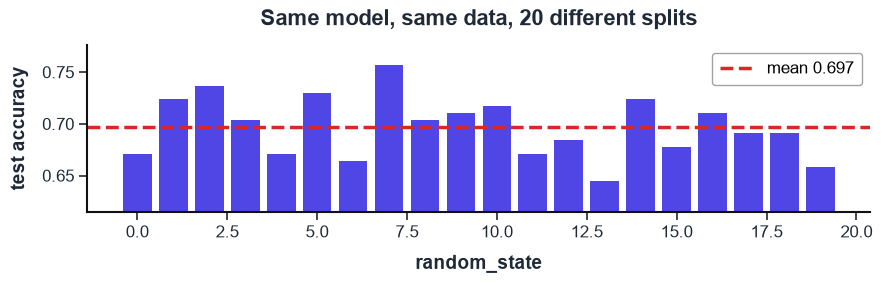

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(scores)), scores, color="#4f46e5")
ax.axhline(scores.mean(), color="#dc2626", linestyle="--",
           label=f"mean {scores.mean():.3f}")
ax.set_ylim(scores.min() - 0.03, scores.max() + 0.02)
ax.set_xlabel("random_state")
ax.set_ylabel("test accuracy")
ax.set_title("Same model, same data, 20 different splits")
ax.legend()
plt.show()

## 2.4 Cross-validation

Instead of holding out one fifth once, hold out each fifth in turn: split the data into *k* folds, train on *k−1* and test on the remaining one, and rotate. Every row is used for training and gets predicted exactly once, and you end up with *k* scores instead of one.

In [6]:
from tuiml.evaluation import cross_val_score

cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=5)

for i, score in enumerate(cv_scores, 1):
    print(f"  fold {i}: {score:.4f}")
print(f"\n  mean {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

  fold 1: 0.6818
  fold 2: 0.6494
  fold 3: 0.7143
  fold 4: 0.7451
  fold 5: 0.7255

  mean 0.7032 ± 0.0339


Look at the fold-to-fold variation. On this dataset it is large — the best fold and the worst fold are far enough apart that any comparison between two models whose means differ by less than that gap is not a comparison at all, it is noise. Chapter 8 makes that intuition into an actual statistical test.

> **Remark — how many folds?** 5 and 10 are the conventions. More folds means more training data per fold (so slightly less pessimistic scores) and more runs (so more compute). 10-fold is the default in most of the literature; 5-fold is the practical choice while iterating. Leave-one-out — *k* = *n* — is available as `LeaveOneOut` and is almost always more expensive than it is worth.

For imbalanced data, use `StratifiedKFold` so every fold keeps the class ratio:

In [7]:
from tuiml.evaluation import StratifiedKFold

stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=stratified)

print(f"stratified 5-fold: {strat_scores.mean():.4f} ± {strat_scores.std():.4f}")

stratified 5-fold: 0.7174 ± 0.0226

## 2.5 Accuracy is the wrong metric

We now have a trustworthy accuracy. It is still the wrong thing to look at.

Recall from chapter 1 that 65% of these patients tested negative. So here is a model that requires no training at all:

In [8]:
from tuiml.algorithms.rules import ZeroRuleClassifier

baseline = ZeroRuleClassifier()
baseline.fit(X_train, y_train)

print(f"baseline accuracy: {accuracy_score(y_test, baseline.predict(X_test)):.4f}")
print(f"our tree:          {accuracy_score(y_test, tree.predict(X_test)):.4f}")

baseline accuracy: 0.6513
our tree:          0.7237


`ZeroRuleClassifier` is exactly what it sounds like: it learns the majority class and predicts it for everything, forever. It exists in the catalog precisely so that this comparison is one line rather than something you have to remember to write.

The tree beats a model that ignores its input entirely — but by far less than the raw accuracy suggests. And the baseline model is worse than useless in this application: it tells every diabetic patient they are fine.

**Always compute the majority-class baseline.** It is the number your accuracy has to be judged against, and it takes one line.

To see what is actually happening, count the four possible outcomes:

In [9]:
from tuiml.evaluation import confusion_matrix

y_pred = tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("                 predicted neg   predicted pos")
print(f"actual negative       {cm[0, 0]:4d}            {cm[0, 1]:4d}")
print(f"actual positive       {cm[1, 0]:4d}            {cm[1, 1]:4d}")

                 predicted neg   predicted pos
actual negative         77              22
actual positive         20              33


The bottom-left cell is the one that matters. Those are patients who **have** diabetes and were told they do not — false negatives. Out of all the positive cases in the test set, the model missed a substantial fraction of them.

The top-right cell — false positives — is people wrongly flagged. In a screening context these two errors are not remotely equal in cost: a false alarm leads to a second test, a missed case leads to an untreated disease. Accuracy adds them together and weights them the same.

In [10]:
from tuiml.evaluation import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))

          class  precision     recall   f1-score    support
tested_negative     0.7938     0.7778     0.7857         99
tested_positive     0.6000     0.6226     0.6111         53
------------------------------------------------------------
       accuracy                           0.7237        152
      macro avg     0.6969     0.7002     0.6984        152



Three metrics decompose that trade-off, all defined for one chosen class:

- **Precision** — of the patients we flagged, what fraction really were positive? Low precision means crying wolf.
- **Recall** (sensitivity) — of the patients who really were positive, what fraction did we catch? Low recall means missing sick people.
- **F1** — the harmonic mean of the two, which is what you report when you need a single number and both errors matter.

Read the `tested_positive` row. Precision and recall there are both far below the overall accuracy, and that row is the entire reason the model exists.

> **Remark — choose the metric before you see the results.** Deciding which metric matters *after* looking at the scores is how you end up reporting whichever one happened to be highest. For screening, recall usually dominates. For a spam filter, precision does — nobody minds a little spam, everybody minds a lost invoice.

## 2.6 The threshold is a choice

The model does not really output a class. It outputs a probability, and something turns that into a class by cutting at 0.5.

That cut-off is not part of the model. You can move it — but first, look at what our tree actually produces:

In [11]:
print("distinct probabilities from the tree:", np.unique(tree.predict_proba(X_test)[:, 1]))

distinct probabilities from the tree: [0. 1.]


Zero and one, and nothing in between. A fully grown decision tree splits until every leaf is pure, so every leaf reports its single class with total confidence. The tree has no notion of "probably". Moving its threshold would therefore do nothing at all — there is nothing between 0 and 1 to cut.

This is a genuine limitation of unpruned trees, and a good reason to reach for an ensemble: a random forest averages hundreds of trees, and the fraction that vote positive is a usable probability.

In [12]:
from tuiml.algorithms.trees import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)

probabilities = forest.predict_proba(X_test)[:, 1]
print(f"{len(np.unique(probabilities))} distinct probabilities, "
      f"ranging {probabilities.min():.2f} to {probabilities.max():.2f}")

132 distinct probabilities, ranging 0.00 to 0.83


In [13]:
from tuiml.evaluation import precision_score, recall_score

print(f"{'threshold':>10s} {'precision':>10s} {'recall':>8s} {'missed cases':>13s}")
print("-" * 45)
for t in (0.7, 0.5, 0.3, 0.2):
    pred_t = (probabilities >= t).astype(int)
    missed = int(((y_test == 1) & (pred_t == 0)).sum())
    print(f"{t:10.1f} {precision_score(y_test, pred_t):10.3f} "
          f"{recall_score(y_test, pred_t):8.3f} {missed:13d}")

 threshold  precision   recall  missed cases
---------------------------------------------
       0.7      0.765    0.245            40
       0.5      0.737    0.528            25
       0.3      0.638    0.830             9
       0.2      0.529    0.868             7


Now the dial works, and the trade-off is stark. At a threshold of 0.7 the model is right about most of what it flags, and misses 40 of the 53 diabetic patients in the test set. At 0.2 it misses 7 — but now nearly half of the people it flags do not have the disease.

There is no setting that improves both. This is a dial you position according to what the errors cost, not a parameter you optimise. For a screening test that feeds into a cheap confirmatory test, something near 0.3 is defensible; 0.5 is defensible only if you have decided the two errors cost the same, which here they plainly do not.

A ROC curve shows the whole dial at once. Every point on it is one threshold.

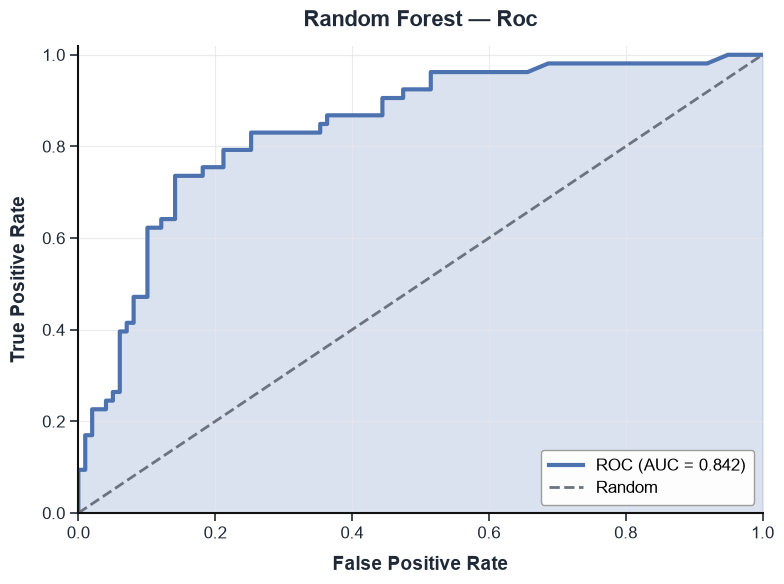

AUC: 0.8416


In [14]:
from tuiml.evaluation import plot_roc_curve, roc_auc_score

plot_roc_curve(y_test, probabilities, title="Random forest — ROC")
plt.show()

print(f"AUC: {roc_auc_score(y_test, probabilities):.4f}")

The area under that curve (AUC) summarises the model across *every* threshold, which makes it useful precisely when you have not yet decided where to cut. 0.5 is a coin flip; 1.0 is perfect separation.

> **Remark — AUC on imbalanced data.** ROC-AUC can look flattering when the negative class dominates, because the false-positive rate has a large denominator. When positives are rare and are what you care about, the precision-recall curve (`plot_pr_curve`) is the more honest picture. Chapter 6 returns to this.

## 2.7 Putting it together

Everything above, as one spec — which is how you would actually run it:

In [15]:
import tuiml

model = tuiml.train({
    "model": {"name": "DecisionTreeClassifier", "params": {"random_state": 42}},
    "data": "diabetes",
    "evaluation": {"cv": 5, "metrics": ["accuracy_score", "f1_score", "recall_score"]},
    "random_seed": 42,
})

for name, value in model.metrics_.items():
    print(f"  {name:32s} {value:.4f}")

  cv_accuracy_score_mean           0.7318
  cv_accuracy_score_std            0.0146
  cv_f1_score_mean                 0.6135
  cv_f1_score_std                  0.0456
  cv_recall_score_mean             0.6186
  cv_recall_score_std              0.0645


Note that `metrics` is explicit here. The default is `"auto"`, which picks sensible metrics for the task — but after this chapter, "sensible" is a decision you should be making yourself.

## Recap

- `fit(X, y)` then `predict(X)`. Scoring on the training data measures memory, not learning — and fails silently, with a beautiful number.
- Hold data back with `train_test_split(..., stratify=y)`. Stratify on imbalanced data; always set `random_state` for reproducibility.
- A single split is a single sample. Twenty seeds gave a spread of several points on identical models.
- `cross_val_score(model, X, y, cv=5)` returns a score per fold. **Report the spread, not just the mean.**
- Compute the majority-class baseline before believing any accuracy — `ZeroRuleClassifier` does it in one line. Here it is 0.65.
- Read the confusion matrix. Precision, recall and F1 separate the two kinds of error; accuracy merges them.
- The 0.5 threshold is a choice. Move it according to what the errors cost, and use ROC/PR curves to see the whole trade-off.
- A fully grown decision tree emits only 0.0 and 1.0, so it has no threshold to move. Ensembles like `RandomForestClassifier` give you graded probabilities — and a much better AUC here.

**Next:** chapter 3 goes back to the impossible zeros from chapter 1 and fixes them — then measures whether the fix was worth anything, and introduces the leakage trap that the two chapters after it demonstrate at full scale.